<a href="https://colab.research.google.com/github/vallabhatech/AUBI/blob/main/Rag.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q datasets sentence-transformers faiss-cpu transformers rank_bm25 accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 62.0 MB/s eta 0:00:00


In [ ]:

import numpy as np
import pandas as pd
import textwrap
import time

from datasets import load_dataset
from sentence_transformers import SentenceTransformer
import faiss
from transformers import pipeline
from rank_bm25 import BM25Okapi

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
def ingest_documents(source_type: str, source_path: str = None, hf_dataset_name: str = None, hf_config: str = None, hf_split: str = "train", text_column: str = "passage"):
    """
    Generic document ingestion module.

    source_type : 'pdf' | 'txt' | 'huggingface'
    source_path : local path to a .pdf or .txt file (used when source_type is 'pdf' or 'txt')
    hf_dataset_name : Hugging Face dataset repo id (used when source_type == 'huggingface')
    hf_config : dataset config/subset name, if the dataset has one
    hf_split : dataset split to load
    text_column : name of the column holding the raw text

    Returns: list[str] of raw document/passage strings
    """
    documents = []

    if source_type == "pdf":
        import PyPDF2
        with open(source_path, "rb") as f:
            reader = PyPDF2.PdfReader(f)
            for page in reader.pages:
                text = page.extract_text()
                if text:
                    documents.append(text)

    elif source_type == "txt":
        with open(source_path, "r", encoding="utf-8") as f:
            documents.append(f.read())

    elif source_type == "huggingface":
        ds = load_dataset(hf_dataset_name, hf_config, split=hf_split)
        documents = [row[text_column] for row in ds if row[text_column] and row[text_column].strip()]

    else:
        raise ValueError("source_type must be one of: 'pdf', 'txt', 'huggingface'")

    print(f"Ingested {len(documents)} document(s)/passage(s) from source_type='{source_type}'")
    return documents


# Ingest the RAG-mini-Wikipedia text corpus (our "custom document" collection)
raw_documents = ingest_documents(
    source_type="huggingface",
    hf_dataset_name="rag-datasets/rag-mini-wikipedia",
    hf_config="text-corpus",
    hf_split="passages",
    text_column="passage"
)

print("\nSample document:\n")
print(textwrap.fill(raw_documents[0], width=100))


README.md:   0%|          | 0.00/719 [00:00<?, ?B/s]

data/passages.parquet/part.0.parquet:   0%|          | 0.00/797k [00:00<?, ?B/s]

Generating passages split:   0%|          | 0/3200 [00:00<?, ? examples/s]

Ingested 3200 document(s)/passage(s) from source_type='huggingface'

Sample document:

Uruguay (official full name in  ; pron.  , Eastern Republic of  Uruguay) is a country located in the
southeastern part of South America.  It is home to 3.3 million people, of which 1.7 million live in
the capital Montevideo and its metropolitan area.


In [ ]:
def clean_text(text: str) -> str:
    """Basic text cleaning: collapse whitespace, strip."""
    return " ".join(text.split()).strip()


def chunk_text(text: str, chunk_size: int = 300, chunk_overlap: int = 50):
    """
    Splits `text` into overlapping chunks of ~chunk_size characters.

    chunk_size    : target number of characters per chunk
    chunk_overlap : number of overlapping characters between consecutive chunks
                    (preserves context continuity across chunk boundaries)

    Returns: list[str] chunks
    """
    text = clean_text(text)
    if len(text) <= chunk_size:
        return [text]

    chunks = []
    start = 0
    step = chunk_size - chunk_overlap
    while start < len(text):
        end = start + chunk_size
        chunk = text[start:end].strip()
        if chunk:
            chunks.append(chunk)
        start += step
    return chunks


CHUNK_SIZE = 300
CHUNK_OVERLAP = 50

all_chunks = []
chunk_source_ids = []   # keeps track of which original document a chunk came from

for doc_id, doc in enumerate(raw_documents):
    doc_chunks = chunk_text(doc, chunk_size=CHUNK_SIZE, chunk_overlap=CHUNK_OVERLAP)
    all_chunks.extend(doc_chunks)
    chunk_source_ids.extend([doc_id] * len(doc_chunks))

print(f"Total documents: {len(raw_documents)}")
print(f"Total chunks created: {len(all_chunks)}")
print(f"Chunk size: {CHUNK_SIZE} chars | Overlap: {CHUNK_OVERLAP} chars")
print("\nExample chunk:\n")
print(textwrap.fill(all_chunks[0], width=100))

Total documents: 3200
Total chunks created: 6581
Chunk size: 300 chars | Overlap: 50 chars

Example chunk:

Uruguay (official full name in ; pron. , Eastern Republic of Uruguay) is a country located in the
southeastern part of South America. It is home to 3.3 million people, of which 1.7 million live in
the capital Montevideo and its metropolitan area.


In [6]:
import kagglehub

# Download latest version
base_download_path = kagglehub.dataset_download("sunnykusawa/cloth-dataset")

print("Path to dataset files:", base_download_path)

Path to dataset files: /root/.cache/kagglehub/datasets/sunnykusawa/cloth-dataset/versions/1


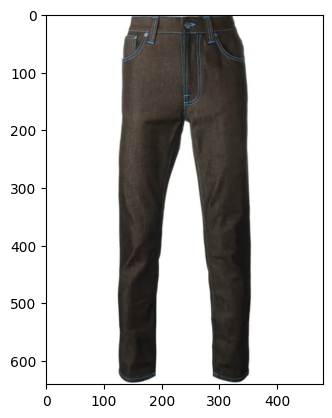

In [7]:
import numpy as np # linear algebra
import os
data_dir = os.path.join(base_download_path, "cloth_dataset") # Using the explicitly named base path
categories = ["jeans","tshirt"]
import cv2 as cv
import matplotlib.pyplot as plt
for category in categories:
    category_path = os.path.join(data_dir,category) # Renaming loop variable to avoid confusion
    for img in os.listdir(category_path): # Using category_path here
        img_array = cv.imread(os.path.join(category_path,img))#,cv.IMREAD_GRAYSCALE)
        # ,cv.IMREAD_GRAYSCALE
        plt.imshow(img_array,cmap = "gray")
        plt.show()
        break
    break

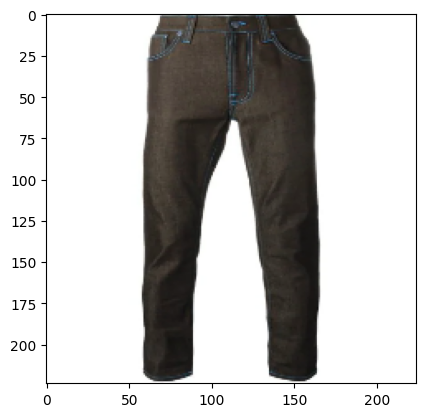

In [12]:
img_size = 224 # Changed from 227 to align with MobileNetV2's default input size
new_array = cv.resize(img_array,(img_size,img_size))
plt.imshow(new_array,cmap='gray')
plt.show()

In [9]:
from tqdm import tqdm

train_data = []
def get_train_data():
    for folders in categories:
        path = os.path.join(data_dir,folders)
        class_num = categories.index(folders)
        for img in tqdm(os.listdir(path)):
            try:
                img_array = cv.imread(os.path.join(path,img))
                new_array = cv.resize(img_array,(img_size,img_size))
                train_data.append([new_array,class_num])
            except Exception as e:
                print("Error Occured:",e)

get_train_data()
print("\nTotal training set:",len(train_data))

100%|██████████| 199/199 [00:00<00:00, 778.25it/s]


Total training set: 398


In [10]:
import random as r
r.shuffle(train_data)

print("Sample labels from shuffled training data:")
for sample in train_data[:10]:
    print(sample[1])

Sample labels from shuffled training data:
1
0
1
0
0
1
0
1
1
1


In [11]:
import tensorflow as tf
from tensorflow import keras

X = []
y = []

for features,labels in train_data:
    X.append(features)
    y.append(labels)

# Normalize pixel values to be between 0 and 1
X = np.array(X) / 255.0

train_labels_categorical = keras.utils.to_categorical(y)

IMG_SHAPE = (img_size, img_size, 3)

base_model = tf.keras.applications.MobileNetV2(input_shape=IMG_SHAPE,
                                                include_top=False,
                                                weights='imagenet')
base_model.trainable = False

/tmp/ipykernel_2687/2622671401.py:18: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(input_shape=IMG_SHAPE,


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [13]:
inputs = tf.keras.Input(shape=IMG_SHAPE)
x = base_model(inputs, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(2, activation='softmax')(x) # 2 categories (jeans, tshirt)

model = tf.keras.Model(inputs, x)

base_learning_rate = 0.0001
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=base_learning_rate),
              loss=tf.keras.losses.CategoricalCrossentropy(), # Use CategoricalCrossentropy for one-hot encoded labels
              metrics=['accuracy'])

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 227, 227, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 8, 8, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │         2,562 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,260,546 (8.62 MB)

 Trainable params: 2,562 (10.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)